<a href="https://colab.research.google.com/github/Leemyunglyul/ai_advanced/blob/main/%5BSDS%5DWS_movie_review_analysis_Q.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 영화 리뷰 텍스트 분석

## 필수 모듈 추가

In [1]:
!pip install tiktoken wordcloud gmteacher -q

In [2]:
from gmteacher import download_file
import zipfile

download_file('ALL')

with zipfile.ZipFile('./data/data.zip', 'r') as f:
    f.extractall('./data/')

Download Completed: ./data/data.zip


In [3]:
import re
from collections import Counter

import pandas as pd
import tiktoken
from wordcloud import WordCloud
import matplotlib.pyplot as plt

## 데이터 확인 및 결측치 처리

In [4]:
# ./data/imdb_reviews.csv 파일을 읽어서 df에 저장하세요.
# 처음 5개 행을 출력하세요.
df = pd.read_csv('./data/imdb_reviews.csv')
df.head()

,제목,내용,점수
0,Not a bad watch but lets be objective,I enjoyed The Odyssey. If you have an idea or ...,7.0
1,An overhyped mixed bag,I went to see this on Imax and the most notice...,7.0
2,The Battle of Spectacle Cost the Film Its Soul,Christopher Nolan's The Odyssey is undeniably ...,NaN
3,Take The Long Way Home,To call Homer's 'Odyssey' merely one of the gr...,8.0
4,Petition to make the sound level bearable,The Odyssey was visually stunning and brillian...,9.0


In [5]:
# df의 정보를 조회하세요.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1102 entries, 0 to 1101
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제목      1102 non-null   object 
 1   내용      1102 non-null   object 
 2   점수      1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 26.0+ KB


In [6]:
# df의 열 별 결측치 개수를 조회하세요.
df.isnull().sum()

,0
제목,0
내용,0
점수,34


In [8]:
# 이번 실습에서는 점수가 있는 리뷰만 분석합니다.
# 점수가 결측치인 행을 제거한 후 열 별 결측치 개수를 다시 조회하세요.
df = df.dropna(subset=['점수'])
df.isnull().sum()

,0
제목,0
내용,0
점수,0


In [11]:
# 점수 열을 정수 타입으로 변환한 후 데이터 타입을 확인하세요.
df['점수'] = df['점수'].astype(int)
df.dtypes

/tmp/ipykernel_965/905861774.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['점수'] = df['점수'].astype(int)


,0
제목,object
내용,object
점수,int64


In [12]:
# 점수 별 리뷰 개수를 조회하세요.
# 점수가 낮은 순서대로 출력하세요.
df.groupby('점수').size().sort_values()

,0
점수,
3,16
4,18
2,28
5,31
7,55
8,102
6,153
9,193
10,472


## 텍스트 정제 및 정규화

In [13]:
# 첫 번째 리뷰의 내용을 text에 저장하고 출력하세요.
text = df['내용'][0]
text

"I enjoyed The Odyssey. If you have an idea or understanding of Homer's Odyssey and these epics that were written many years ago, you'd appreciate the artistry and storyline of the film. The Odyssey has been receiving a lot of praise and hype already. But I feel this hype is not objectively for the film but because of Christopher Nolan himself. It seems anything he touches is regarded a masterpiece without objectively analysing its merits. Nolan has directed some of the best, if not best, science fiction films I've seen in Inception. But when he's put his hand to historical films (Dunkirk or Oppenheimer) I've been underwhelmed. The question viewers should ask themselves is does a retelling of an already published epic make this an exceptional film? What distinguishes it? Does Nolan allow you to lift themes from the existing works in these times that is thought provoking? One of the things I noted was the use of 'Dad' twice when Telemachus calls out to Odysseus. This might have been a i

In [14]:
# text의 영문을 소문자로 변환한 후 출력하세요.
text = text.lower()
text

"i enjoyed the odyssey. if you have an idea or understanding of homer's odyssey and these epics that were written many years ago, you'd appreciate the artistry and storyline of the film. the odyssey has been receiving a lot of praise and hype already. but i feel this hype is not objectively for the film but because of christopher nolan himself. it seems anything he touches is regarded a masterpiece without objectively analysing its merits. nolan has directed some of the best, if not best, science fiction films i've seen in inception. but when he's put his hand to historical films (dunkirk or oppenheimer) i've been underwhelmed. the question viewers should ask themselves is does a retelling of an already published epic make this an exceptional film? what distinguishes it? does nolan allow you to lift themes from the existing works in these times that is thought provoking? one of the things i noted was the use of 'dad' twice when telemachus calls out to odysseus. this might have been a i

In [15]:
# text에서 영문 소문자와 공백을 제외한 문자를 공백으로 치환하세요.
text = re.sub('[^a-z ]', ' ', text)
text

'i enjoyed the odyssey  if you have an idea or understanding of homer s odyssey and these epics that were written many years ago  you d appreciate the artistry and storyline of the film  the odyssey has been receiving a lot of praise and hype already  but i feel this hype is not objectively for the film but because of christopher nolan himself  it seems anything he touches is regarded a masterpiece without objectively analysing its merits  nolan has directed some of the best  if not best  science fiction films i ve seen in inception  but when he s put his hand to historical films  dunkirk or oppenheimer  i ve been underwhelmed  the question viewers should ask themselves is does a retelling of an already published epic make this an exceptional film  what distinguishes it  does nolan allow you to lift themes from the existing works in these times that is thought provoking  one of the things i noted was the use of  dad  twice when telemachus calls out to odysseus  this might have been a i

In [16]:
# text에서 연속된 공백을 하나의 공백으로 통일하고 앞뒤 공백을 제거하세요.
text = re.sub('\s+', ' ', text)
text = text.strip()
text

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_965/3641899022.py:2: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text)


'i enjoyed the odyssey if you have an idea or understanding of homer s odyssey and these epics that were written many years ago you d appreciate the artistry and storyline of the film the odyssey has been receiving a lot of praise and hype already but i feel this hype is not objectively for the film but because of christopher nolan himself it seems anything he touches is regarded a masterpiece without objectively analysing its merits nolan has directed some of the best if not best science fiction films i ve seen in inception but when he s put his hand to historical films dunkirk or oppenheimer i ve been underwhelmed the question viewers should ask themselves is does a retelling of an already published epic make this an exceptional film what distinguishes it does nolan allow you to lift themes from the existing works in these times that is thought provoking one of the things i noted was the use of dad twice when telemachus calls out to odysseus this might have been a intentional use to 

In [20]:
# 앞에서 수행한 소문자 변환, 문자 치환, 공백 정리를 clean_text 함수로 작성하세요.
# 내용 열에 적용하여 cleaned 열을 생성한 후 원본과 함께 처음 5개 행을 출력하세요.
def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-z ]', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip()
    return text

df['cleaned'] = df['내용'].apply(clean_text)
df[['내용', 'cleaned']].head()


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_965/4205125437.py:6: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text)


,내용,cleaned
0,I enjoyed The Odyssey. If you have an idea or ...,i enjoyed the odyssey if you have an idea or u...
1,I went to see this on Imax and the most notice...,i went to see this on imax and the most notice...
3,To call Homer's 'Odyssey' merely one of the gr...,to call homer s odyssey merely one of the grea...
4,The Odyssey was visually stunning and brillian...,the odyssey was visually stunning and brillian...
5,Maybe don't take things so seriously. I went i...,maybe don t take things so seriously i went in...


## 텍스트 분할 및 가공

In [21]:
# cleaned 열을 공백 기준으로 분할하여 tokens 열에 저장하세요.
# cleaned와 tokens 열의 처음 5개 행을 출력하세요.
df['tokens'] = df['cleaned'].str.split()
df[['cleaned', 'tokens']].head()


,cleaned,tokens
0,i enjoyed the odyssey if you have an idea or u...,"[i, enjoyed, the, odyssey, if, you, have, an, ..."
1,i went to see this on imax and the most notice...,"[i, went, to, see, this, on, imax, and, the, m..."
3,to call homer s odyssey merely one of the grea...,"[to, call, homer, s, odyssey, merely, one, of,..."
4,the odyssey was visually stunning and brillian...,"[the, odyssey, was, visually, stunning, and, b..."
5,maybe don t take things so seriously i went in...,"[maybe, don, t, take, things, so, seriously, i..."


In [22]:
# cl100k_base 인코더를 생성하세요.
# 첫 번째 리뷰의 제목을 부분 단어 기반으로 토큰화하여 token_ids에 저장하세요.
# 각 토큰을 디코딩한 문자열 목록과 토큰 ID 목록을 순서대로 출력하세요.
encoder = tiktoken.get_encoding('cl100k_base')
text = df['제목'].iloc[0]
token_ids = encoder.encode(text)
tokens = [encoder.decode([token_id]) for token_id in token_ids]
print(tokens)
print(token_ids)


['Not', ' a', ' bad', ' watch', ' but', ' lets', ' be', ' objective']
[2688, 264, 3958, 3821, 719, 15714, 387, 16945]


In [23]:
# cleaned 열에 encoder.encode를 적용하여 token_ids 열을 생성하세요.
# cleaned와 token_ids 열의 처음 5개 행을 출력하세요.
df['token_ids'] = df.cleaned.apply(lambda x: encoder.encode(x))
df[['cleaned', 'token_ids']].head()


,cleaned,token_ids
0,i enjoyed the odyssey if you have an idea or u...,"[72, 14333, 279, 11018, 54347, 422, 499, 617, ..."
1,i went to see this on imax and the most notice...,"[72, 4024, 311, 1518, 420, 389, 737, 710, 323,..."
3,to call homer s odyssey merely one of the grea...,"[998, 1650, 92405, 274, 11018, 54347, 16632, 8..."
4,the odyssey was visually stunning and brillian...,"[1820, 11018, 54347, 574, 43395, 20441, 323, 7..."
5,maybe don t take things so seriously i went in...,"[37860, 1541, 259, 1935, 2574, 779, 14243, 602..."


## 텍스트 데이터 통계

In [24]:
# cleaned의 문자 수를 char_count 열에 저장하세요.
# tokens와 token_ids의 원소 수를 각각 word_count와 subword_count 열에 저장하세요.
# 제목과 세 개의 개수 열을 처음 5개 행만 출력하세요.
df['char_count'] = df.cleaned.str.len()
df['word_count'] = df.tokens.apply(len)
df['subword_count'] = df.token_ids.apply(len)
df[['제목', 'char_count', 'word_count', 'subword_count']].head()


,제목,char_count,word_count,subword_count
0,Not a bad watch but lets be objective,1274,233,257
1,An overhyped mixed bag,549,112,119
3,Take The Long Way Home,8644,1364,1570
4,Petition to make the sound level bearable,291,45,46
5,A word to the comment section movie critics,449,86,93


In [26]:
# char_count, word_count, subword_count 열의 기본 통계량을 조회하세요.
df[['char_count', 'word_count', 'subword_count']].describe()

,char_count,word_count,subword_count
count,1068.00000,1068.000000,1068.000000
mean,1038.75000,185.766854,199.890449
std,1069.53476,187.027402,203.732730
min,283.00000,45.000000,46.000000
25%,381.75000,71.000000,75.000000
50%,665.50000,118.500000,127.000000
75%,1272.50000,225.000000,242.250000
max,8644.00000,1597.000000,1751.000000


In [27]:
# word_count가 큰 순서대로 리뷰 5개를 조회하세요.
# 제목, 점수, word_count 열만 출력하세요.
df.sort_values('word_count', ascending=False)[['제목', '점수', 'word_count']].head()

,제목,점수,word_count
447,One of the Best Blockbusters of the Decade,10,1597
220,Cinema,10,1501
850,The Odyssey (2026) - A Spectacularly Overhyped...,4,1381
3,Take The Long Way Home,8,1364
129,Saw it twice. A Technical Masterpiece but not ...,8,1348


In [28]:
# tokens 열의 리스트를 explode로 펼쳐 words에 저장하세요.
# value_counts로 단어 별 빈도를 집계하여 word_counts에 저장하세요.
# 빈도가 높은 단어 20개를 출력하세요.
words = df.tokens.explode()
word_counts = words.value_counts()[:20]
word_counts


,count
tokens,
the,12840
and,5925
of,4944
a,4802
to,3977
it,3968
i,3578
is,3521
in,2542


In [30]:
# words를 리스트로 변환하고 Counter로 단어 별 빈도를 집계하세요.
# 빈도가 높은 단어 20개를 출력하세요.
word_counts2 = Counter(words.tolist())
print(word_counts2.most_common(20))

[('the', 12840), ('and', 5925), ('of', 4944), ('a', 4802), ('to', 3977), ('it', 3968), ('i', 3578), ('is', 3521), ('in', 2542), ('that', 2498), ('s', 2366), ('this', 1962), ('was', 1891), ('film', 1621), ('nolan', 1611), ('but', 1550), ('with', 1513), ('movie', 1416), ('for', 1381), ('as', 1266)]


## 워드클라우드

In [31]:
# words를 하나의 문자열로 합쳐 text_for_cloud에 저장하세요.
# 단어 사이에는 공백 하나를 넣고, 결과의 앞 200자를 출력하세요.
text_for_cloud = ' '.join(words)
print(text_for_cloud[:200])


i enjoyed the odyssey if you have an idea or understanding of homer s odyssey and these epics that were written many years ago you d appreciate the artistry and storyline of the film the odyssey has b


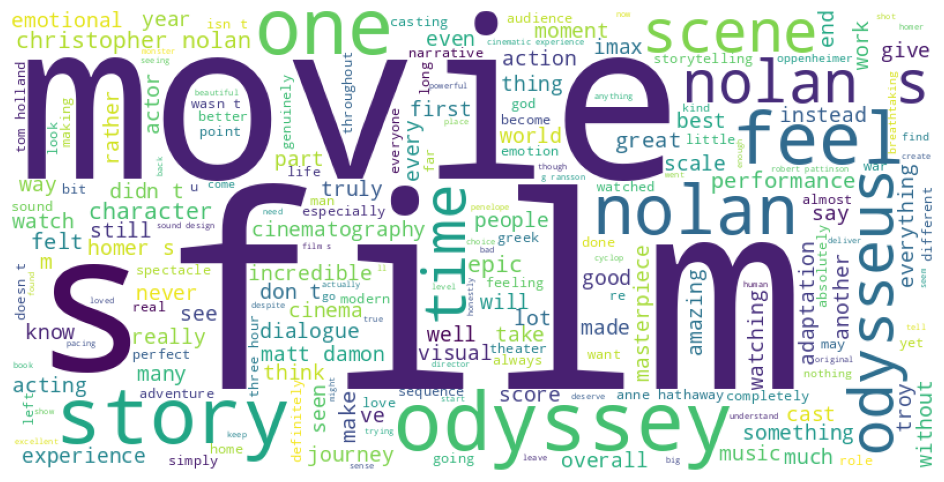

In [32]:
# text_for_cloud로 워드클라우드를 생성하세요.
# 너비 800, 높이 400, 흰색 배경, random_state=42로 설정하세요.
wc = WordCloud(width=800, height=400, background_color='white', random_state=42).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wc)
plt.axis('off')
plt.show()